## SafeDerm — 03. Exploratory Data Analysis

Explores the **training split only** — `train_split.csv`. Val and test stay untouched here; looking at them now would let their content quietly influence modeling decisions, which defeats the point of holding them out in `02_data_understanding.ipynb`.

Goal: understand class balance, label confidence, demographics, body-site distribution, and get a visual sense of what these lesions actually look like — before any modeling starts. No modeling decisions get made in this notebook, only observations.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH

train_df = pd.read_csv(TRAIN_SPLIT_PATH)
print(f"Training images: {len(train_df)}")
train_df.head()

Training images: 6981


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Class distribution

The 7 diagnostic classes, on the training split only.

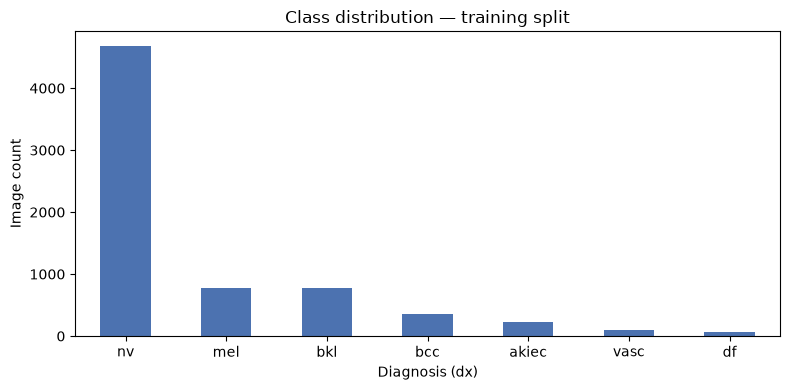

dx
nv       4683
mel       773
bkl       772
bcc       361
akiec     222
vasc       99
df         71
Name: count, dtype: int64


In [2]:
class_counts = train_df["dx"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Class distribution — training split")
ax.set_xlabel("Diagnosis (dx)")
ax.set_ylabel("Image count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(class_counts)

### Malignant vs benign

The coarser grouping your triage system's actual safety metric (recall on the malignant class) is built around. Standard grouping for this dataset: **malignant** = melanoma (`mel`), basal cell carcinoma (`bcc`), actinic keratosis (`akiec` — precancerous). **Benign** = everything else (`nv`, `bkl`, `df`, `vasc`).

Flagging this explicitly since it's a modeling-relevant assumption — confirm with your team it matches what's in the Project Guide before it's relied on elsewhere. This grouping is computed here for visualization only, not saved back to any file.

dx
benign       5625
malignant    1356
Name: count, dtype: int64

Malignant: 19.4%
Benign   : 80.6%


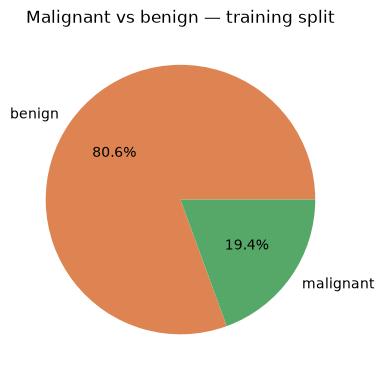

In [3]:
MALIGNANT_CLASSES = {"mel", "bcc", "akiec"}

risk_group = train_df["dx"].apply(lambda dx: "malignant" if dx in MALIGNANT_CLASSES else "benign")
risk_counts = risk_group.value_counts()
risk_pct = risk_group.value_counts(normalize=True) * 100

print(risk_counts)
print(f"\nMalignant: {risk_pct['malignant']:.1f}%")
print(f"Benign   : {risk_pct['benign']:.1f}%")

fig, ax = plt.subplots(figsize=(4, 4))
risk_counts.plot(kind="pie", ax=ax, autopct="%1.1f%%", colors=["#DD8452", "#55A868"])
ax.set_ylabel("")
ax.set_title("Malignant vs benign — training split")
plt.tight_layout()
plt.show()

### Label confidence — `dx_type`

Not all labels come from the same source. Some are confirmed by biopsy (`histo`), others by follow-up exam, expert consensus, or confocal microscopy. A biopsy-confirmed label is stronger ground truth than a consensus-based one — worth knowing this split if you ever need to inspect misclassified cases later and judge how much to trust the label itself.

dx_type
histo        3690
follow_up    2592
consensus     653
confocal       46
Name: count, dtype: int64


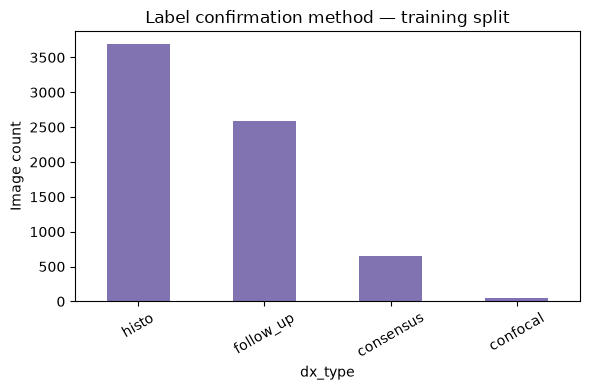

In [4]:
dx_type_counts = train_df["dx_type"].value_counts()
print(dx_type_counts)

fig, ax = plt.subplots(figsize=(6, 4))
dx_type_counts.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Label confirmation method — training split")
ax.set_xlabel("dx_type")
ax.set_ylabel("Image count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Demographics — age and sex

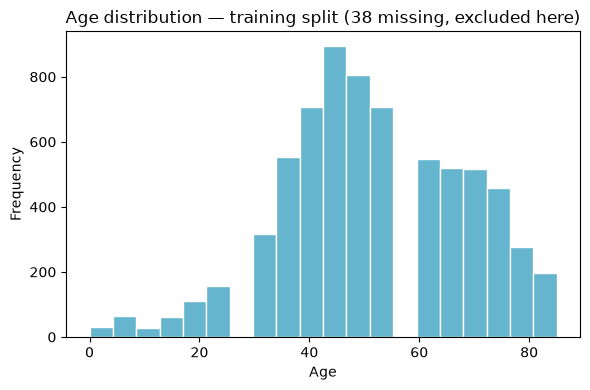

count    6943.000000
mean       51.825580
std        17.040193
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


In [5]:
n_missing_age = train_df["age"].isna().sum()

fig, ax = plt.subplots(figsize=(6, 4))
train_df["age"].dropna().plot(kind="hist", bins=20, ax=ax, color="#64B5CD", edgecolor="white")
ax.set_title(f"Age distribution — training split ({n_missing_age} missing, excluded here)")
ax.set_xlabel("Age")
plt.tight_layout()
plt.show()

print(train_df["age"].describe())

In [6]:
print(train_df["sex"].value_counts())

sex
male       3795
female     3151
unknown      35
Name: count, dtype: int64


### Body site (`localization`)

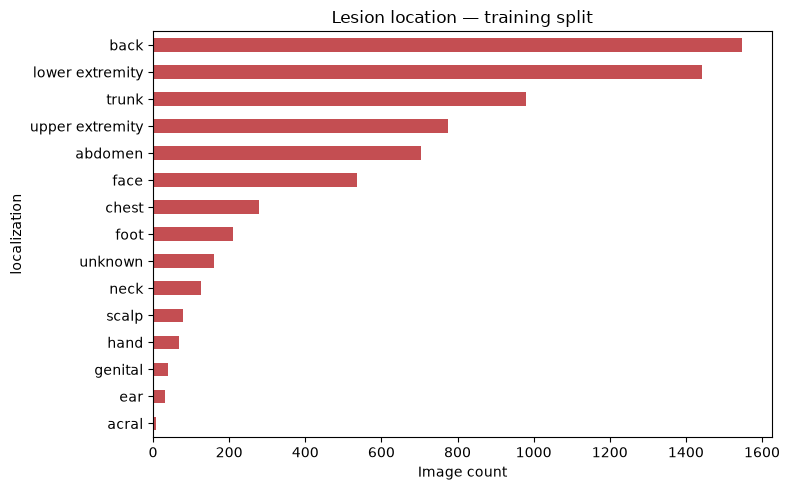

In [7]:
loc_counts = train_df["localization"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
loc_counts.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Lesion location — training split")
ax.set_xlabel("Image count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Sample images — one row per class

A visual sanity check. Confirms the images actually match their labels, and gives a first look at how visually similar some classes are — part of why this is a genuinely hard classification problem, not a "just train a CNN" one.

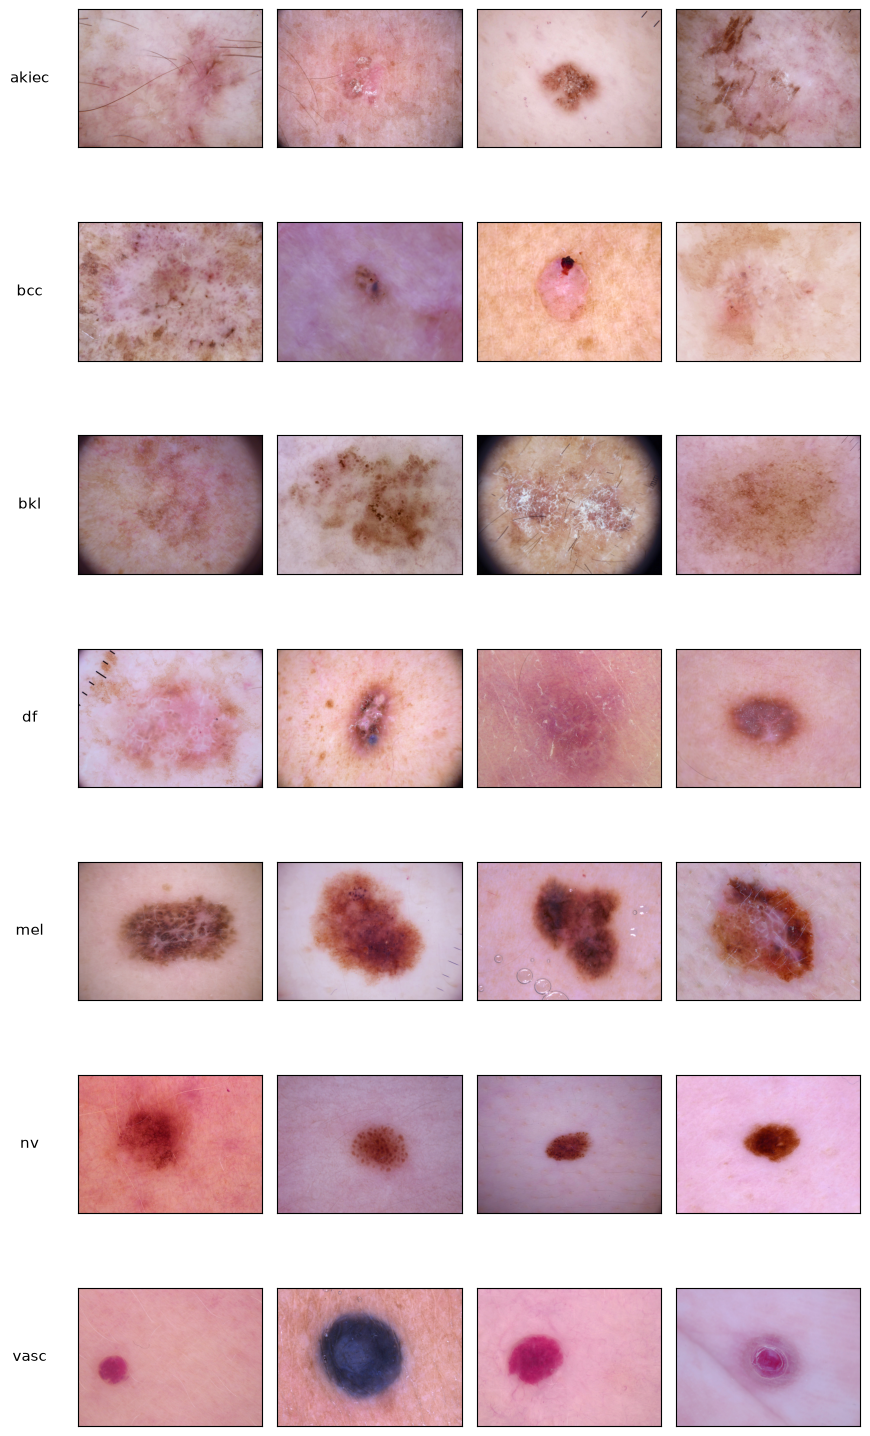

In [8]:
classes = sorted(train_df["dx"].unique())
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.2, len(classes) * 2.2))

for row, dx in enumerate(classes):
    sample_ids = train_df[train_df["dx"] == dx]["image_id"].sample(n_samples, random_state=42)
    for col, image_id in enumerate(sample_ids):
        img = Image.open(IMAGES_DIR / f"{image_id}.jpg")
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(dx, fontsize=11, rotation=0, labelpad=35, va="center")

plt.tight_layout()
plt.show()

### Image dimensions

Confirms images share a consistent resolution before any resizing decisions get made in `04_feature_engineering.ipynb`. If sizes vary, preprocessing needs to account for that.

In [9]:
sample_ids = train_df["image_id"].sample(50, random_state=42)
sizes = {Image.open(IMAGES_DIR / f"{img_id}.jpg").size for img_id in sample_ids}

print(f"Unique image sizes found in a 50-image sample: {sizes}")

Unique image sizes found in a 50-image sample: {(600, 450)}


### Summary

- Class imbalance confirmed on the training split — this is what the weighted loss function in the Project Guide is designed to counter.
- Label confidence varies by `dx_type` — biopsy-confirmed (`histo`) is the strongest ground truth.
- Image resolution confirmed consistent above — informs the resize strategy next.
- No modeling or preprocessing decisions made here. `04_feature_engineering.ipynb` is where those choices get made and justified.